In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [226]:
df=pd.read_csv('data.csv')

In [227]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [228]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [229]:
df.shape

(2000, 12)

In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [231]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Text(0.5, 1.0, 'Distribution of Completion Rate')

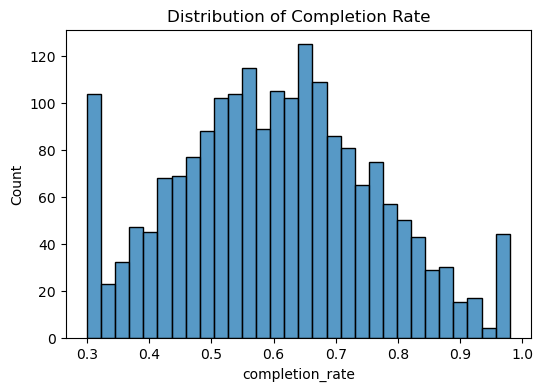

In [232]:
plt.figure(figsize=(6,4))
sns.histplot(df["completion_rate"], bins=30)
plt.title("Distribution of Completion Rate")

<Axes: xlabel='dropout_rate', ylabel='Count'>

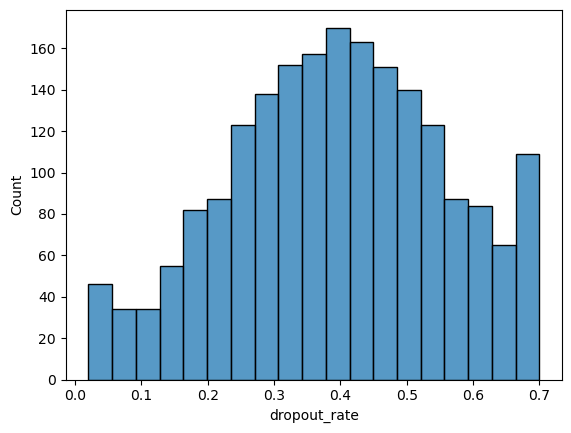

In [233]:
sns.histplot(df["dropout_rate"])

<Axes: xlabel='avg_feedback_score', ylabel='Count'>

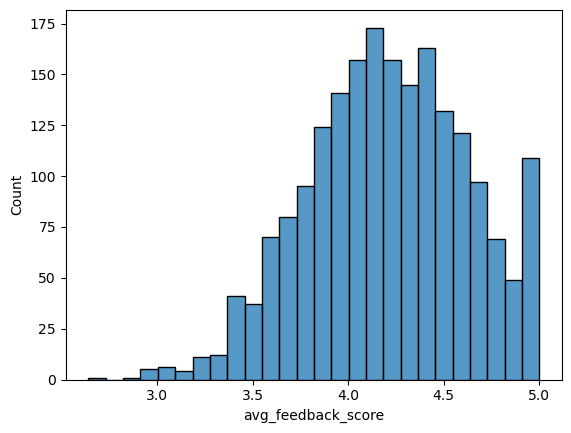

In [234]:
sns.histplot(df["avg_feedback_score"])

In [235]:
df["learning_score"] = (
    0.4 * df["completion_rate"] +
    0.3 * (1 - df["dropout_rate"]) +
    0.2 * df["avg_score_improvement"] +
    0.1 * df["avg_quiz_score"]/100
)

In [236]:
df["engagement_score"] = (
    0.6 * df["avg_watch_time"] +
    0.4 * df["assignment_submission_rate"]
)

In [237]:
df["feedback_score"] = df["avg_feedback_score"]/5

I am not choosing all the features since some of them highly correlate, we dont want to overweight the dimension, hence only 2 out of 3 have been chosen in engagement and only 1 is chosen from the feedback metrics

In [238]:
df["effectiveness_score"] = (
    0.5 * df["learning_score"] +
    0.25 * df["engagement_score"] +
    0.25 * df["feedback_score"]
)

Since the instructor's effectiveness highly depends on how students grasp/learn a particular course, then subsequently the engagement and the feedback, I will keep the half of the dependency on the learning score, we can split the next into equal halves as both of them carry the same amount of importance.

In [239]:
# splitting into 3 halves, using qcut instea of cut for uniform distribution of data, qcut is quantile based, if we use cut our data will be highly skewed, we dont want that
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

In [240]:
df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

In [241]:
instructor_df = df.groupby("instructor_id").mean(numeric_only=True).reset_index()

In [242]:
batch_counts = df.groupby("instructor_id").size().reset_index(name="batch_count")

instructor_df = instructor_df.merge(batch_counts, on="instructor_id")

In [243]:
instructor_df["tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

In [244]:
instructor_df.head(10)

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,learning_score,engagement_score,feedback_score,effectiveness_score,batch_count,tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,5.783570,0.750665,0.843549,3.290338,25,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,6.633177,0.812193,0.868600,3.736787,20,High
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,6.614084,0.802907,0.890007,3.730270,18,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,4.979237,0.779205,0.815282,2.888240,17,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,7.203737,0.858992,0.840503,4.026743,19,High
5,I_006,0.411643,21.930795,71.985054,0.576765,0.716312,0.671114,0.210121,4.065407,0.636827,4.749772,0.698233,0.813081,2.752715,15,Low
6,I_007,0.705245,31.219761,80.288353,0.295653,0.807712,0.778043,0.298642,4.263276,0.760659,6.817643,0.795844,0.852655,3.820946,15,High
7,I_008,0.638368,28.342337,79.387063,0.351231,0.804958,0.748232,0.266687,4.315865,0.790199,6.197833,0.782267,0.863173,3.510276,20,Medium
8,I_009,0.653725,26.982814,73.975231,0.364296,0.743541,0.773957,0.241420,4.355538,0.757300,5.922739,0.755707,0.871108,3.368073,18,Medium
9,I_010,0.940783,34.856747,90.656473,0.068522,0.900853,0.837532,0.343266,4.552640,0.891873,7.717763,0.875525,0.910528,4.305394,13,High


I chose to count the number of batches because the instructor with more number of batches is more reliable than the one with less number of batches

I will use 2 ML algos here, Decision tree and Random forest
Since its a classfication problem we are prediciting the instructor's effectiveness, hence we use tree based models, in which Random forest is an Ensemble model, I think the accuracy might be more in Random forest since it will reduce overfitting, it will train many trees at once, the accuracy actually might go up, but lets check ti

In [245]:
X = instructor_df.drop(["instructor_id","tier","effectiveness_score","avg_feedback_score"], axis=1)
y = instructor_df["tier"]

In [246]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [247]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [248]:
from sklearn.metrics import classification_report
print("Results")
print(classification_report(y_test, pred))

Results
              precision    recall  f1-score   support

        High       0.91      0.91      0.91        11
         Low       1.00      1.00      1.00        10
      Medium       0.93      0.93      0.93        15

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.94      0.94      0.94        36



In [249]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [250]:
print("Results")
print(classification_report(y_test, rf_pred))

Results
              precision    recall  f1-score   support

        High       0.92      1.00      0.96        11
         Low       1.00      0.90      0.95        10
      Medium       0.93      0.93      0.93        15

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [251]:
df['instructor_id'].value_counts()

instructor_id
I_062    31
I_101    27
I_099    26
I_033    26
I_092    26
         ..
I_041     8
I_091     8
I_077     8
I_031     8
I_102     7
Name: count, Length: 120, dtype: int64

Since we only had the data for 120 instructors out of which 20% which is only 24 instructors were tested, which is small sample size, this is the reason we have a high accuracy, lets change the size to 30% to see the changes

Now since we increased the test set to 30%, While we reduced the training data from 80 to 70, we only saw a slight change of 2% in the accuracy, which suggests that the model generalizes reasonably well and is not overly dependent on a specific data split.

We are not going for hyperparamter tuning, because the test size is very low, the results might be unreliable

Text(0.5, 1.0, 'Feature Importance(Random Forests)')

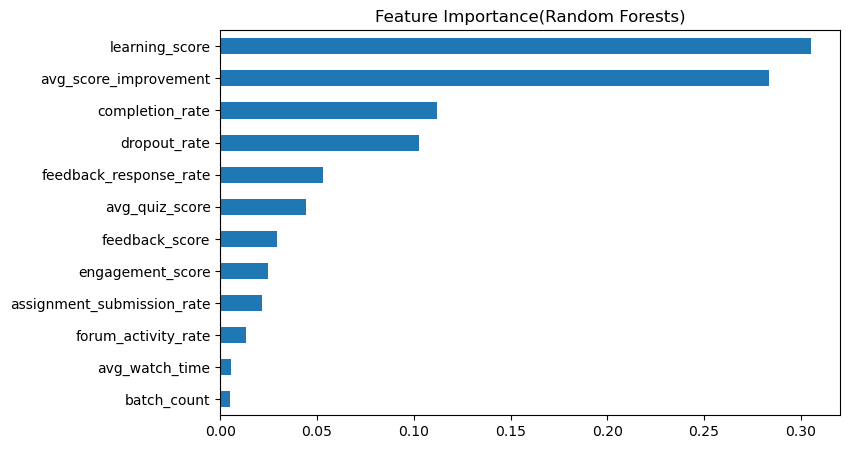

In [252]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

importances.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance(Random Forests)")

Text(0.5, 1.0, 'Feature Importance(Decision Tree)')

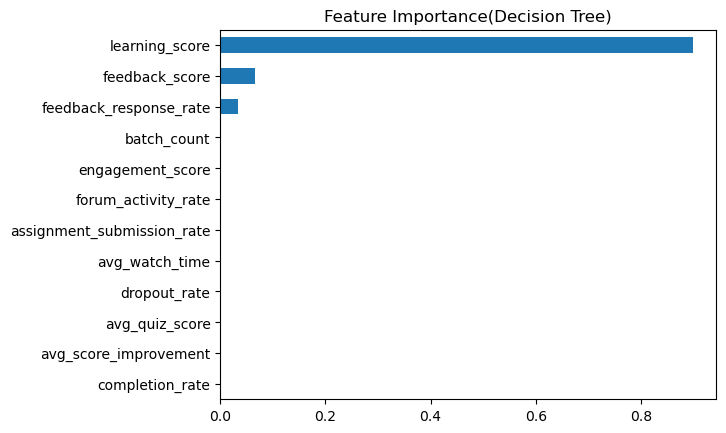

In [253]:
dt_importances = pd.Series(model.feature_importances_, index=X.columns)
dt_importances.sort_values().plot(kind="barh")
plt.title("Feature Importance(Decision Tree)")

The Decision Tree model assigns very high importance to the engineered learning score feature.
This actually indicates that the tree relied almost entirely on that feature and ignored the rest.
While random forest distributed the features equally, as said earlier, in such cases Random forest is actually very effective because of the ensemble method

### Questions and Answers